# Baseline Model Comparison

This notebook compares the existing XGBoost-based Staten Island Railway OTP forecasting model against traditional baseline forecasting methods.

The baseline models include:
- Naive forecast
- 3-month moving average
- 6-month moving average
- SARIMA
- Prophet

The goal is to evaluate whether the machine learning model provides meaningful predictive improvement beyond simpler time-series forecasting methods.

imports and setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Create output folders if they do not already exist
os.makedirs("../outputs/reports", exist_ok=True)
os.makedirs("../outputs/predictions", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

## Load Cleaned OTP Dataset

This section loads the cleaned Staten Island Railway OTP dataset. The baseline models only require a monthly date column and OTP target variable, so the cleaned monthly OTP file is sufficient for the naive, moving average, SARIMA, and Prophet models.

In [5]:
# Load feature-engineered dataset
df = pd.read_csv("../data/raw/cleaned_staten_island_otp.csv")

# Display first few rows
df.head()

,Month,Day Time,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,Trip Complete Percentage,Year,Month_Number,Month_Name
0,2006-01-01,Weekday,83,2621,0.969,124,2580,0.954,2704,NaN,NaN,2006,1,January
1,2006-01-01,AM Rush,21,672,0.970,24,669,0.965,693,NaN,NaN,2006,1,January
2,2006-01-01,PM Rush,10,830,0.988,34,806,0.960,840,NaN,NaN,2006,1,January
3,2006-01-01,Weekend,96,722,0.883,103,715,0.874,818,NaN,NaN,2006,1,January
4,2006-01-01,7-Day,179,3343,0.949,227,3295,0.936,3522,10.0,99.7,2006,1,January


In [6]:
df.columns

Index(['Month', 'Day Time', 'Delayed Trains', 'On-Time Trips',
       'On-Time Performance', 'Delayed Trains (With Boat)',
       'On-Time Trips (With Boat)', 'On-Time Performance (With Boat)',
       'Scheduled Trips', 'Incomplete Trips', 'Trip Complete Percentage',
       'Year', 'Month_Number', 'Month_Name'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Month                            1205 non-null   object 
 1   Day Time                         1205 non-null   object 
 2   Delayed Trains                   1205 non-null   int64  
 3   On-Time Trips                    1205 non-null   int64  
 4   On-Time Performance              1205 non-null   float64
 5   Delayed Trains (With Boat)       1205 non-null   int64  
 6   On-Time Trips (With Boat)        1205 non-null   int64  
 7   On-Time Performance (With Boat)  1205 non-null   float64
 8   Scheduled Trips                  1205 non-null   int64  
 9   Incomplete Trips                 241 non-null    float64
 10  Trip Complete Percentage         241 non-null    float64
 11  Year                             1205 non-null   int64  
 12  Month_Number        

# Set Date and Target Columns
## Inspect Columns

Before preparing the time series, the dataset columns are reviewed to identify the date column, target column, and service-period category column.

In [8]:
date_col = "Month"
target_col = "On-Time Performance"

# Convert date column to datetime
df[date_col] = pd.to_datetime(df[date_col])

# Filter only 7-Day OTP records
df_7day = df[df["Day Time"] == "7-Day"].copy()

# Sort by month
df_7day = df_7day.sort_values(date_col).reset_index(drop=True)

# Convert target to numeric
df_7day[target_col] = pd.to_numeric(df_7day[target_col], errors="coerce")

# Convert OTP from decimal to percentage scale
df_7day["otp"] = df_7day[target_col] * 100

df_7day[[date_col, "Day Time", target_col, "otp"]].head()

,Month,Day Time,On-Time Performance,otp
0,2006-01-01,7-Day,0.949,94.9
1,2006-02-01,7-Day,0.984,98.4
2,2006-03-01,7-Day,1.000,100.0
3,2006-04-01,7-Day,0.965,96.5
4,2006-05-01,7-Day,0.968,96.8


# Prepare Monthly Time Series

In [9]:
ts_df = df_7day[[date_col, "otp"]].copy()

ts_df = ts_df.rename(columns={
    date_col: "month"
})

ts_df = ts_df.dropna()
ts_df = ts_df.sort_values("month").reset_index(drop=True)

print("Time series shape:", ts_df.shape)
print("Start date:", ts_df["month"].min())
print("End date:", ts_df["month"].max())

ts_df.head()

Time series shape: (241, 2)
Start date: 2006-01-01 00:00:00
End date: 2026-01-01 00:00:00


,month,otp
0,2006-01-01,94.9
1,2006-02-01,98.4
2,2006-03-01,100.0
3,2006-04-01,96.5
4,2006-05-01,96.8


In [10]:
ts_df.tail()

,month,otp
236,2025-09-01,98.6
237,2025-10-01,97.4
238,2025-11-01,92.2
239,2025-12-01,98.0
240,2026-01-01,96.4


# Time-based Train-Test split

In [11]:
test_size = 6

train = ts_df.iloc[:-test_size].copy()
test = ts_df.iloc[-test_size:].copy()

print("Training period:")
print(train["month"].min(), "to", train["month"].max())

print("\nTesting period:")
print(test["month"].min(), "to", test["month"].max())

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

test

Training period:
2006-01-01 00:00:00 to 2025-07-01 00:00:00

Testing period:
2025-08-01 00:00:00 to 2026-01-01 00:00:00

Train shape: (235, 2)
Test shape: (6, 2)


,month,otp
235,2025-08-01,96.6
236,2025-09-01,98.6
237,2025-10-01,97.4
238,2025-11-01,92.2
239,2025-12-01,98.0
240,2026-01-01,96.4


## Evaluation Metrics

Each model is evaluated using MAE, RMSE, R², and MAPE.

MAE is the most interpretable metric for this project because it represents the average prediction error in OTP percentage points. For example, an MAE of 1.20 means the model is off by about 1.20 OTP percentage points on average.

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate model predictions using standard regression metrics.

    MAE and RMSE are measured in OTP percentage points.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # MAPE with protection against zero values
    mape = np.mean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
    ) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [13]:
results = []

# Naive Baseline

In [14]:
naive_predictions = []

history = list(train["otp"])

for actual in test["otp"]:
    pred = history[-1]
    naive_predictions.append(pred)
    history.append(actual)

test["naive_pred"] = naive_predictions

results.append(
    evaluate_model(
        test["otp"],
        test["naive_pred"],
        "Naive Baseline"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.79817


# 3-Month Moving Average Baseline.

In [15]:
moving_avg_3_predictions = []

history = list(train["otp"])
window = 3

for actual in test["otp"]:
    pred = np.mean(history[-window:])
    moving_avg_3_predictions.append(pred)
    history.append(actual)

test["moving_avg_3_pred"] = moving_avg_3_predictions

results.append(
    evaluate_model(
        test["otp"],
        test["moving_avg_3_pred"],
        "3-Month Moving Average"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.798170
1,3-Month Moving Average,1.755556,2.461631,-0.399812,1.850687


# 6-Month Moving Average Baseline.

In [16]:
moving_avg_6_predictions = []

history = list(train["otp"])
window = 6

for actual in test["otp"]:
    pred = np.mean(history[-window:])
    moving_avg_6_predictions.append(pred)
    history.append(actual)

test["moving_avg_6_pred"] = moving_avg_6_predictions

results.append(
    evaluate_model(
        test["otp"],
        test["moving_avg_6_pred"],
        "6-Month Moving Average"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.798170
1,3-Month Moving Average,1.755556,2.461631,-0.399812,1.850687
2,6-Month Moving Average,1.486111,2.344250,-0.269496,1.574264


# SARIMA Baseline

In [17]:
sarima_train = train.set_index("month")["otp"]

# Make sure the index has monthly frequency
sarima_train = sarima_train.asfreq("MS")

# Fill any missing monthly gaps if they exist
sarima_train = sarima_train.interpolate()

sarima_model = SARIMAX(
    sarima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))

test["sarima_pred"] = sarima_forecast.values

results.append(
    evaluate_model(
        test["otp"],
        test["sarima_pred"],
        "SARIMA"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.798170
1,3-Month Moving Average,1.755556,2.461631,-0.399812,1.850687
2,6-Month Moving Average,1.486111,2.344250,-0.269496,1.574264
3,SARIMA,2.335701,2.775295,-0.779270,2.436801


# Prophet Baseline 

In [19]:
pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 43.2 MB/s eta 0:00:001m42.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [prophet]━━━ 3/4 [prophet]y]
Note: you may need to restart the kernel to use updated packages.


In [20]:
try:
    from prophet import Prophet
    prophet_available = True
    print("Prophet is installed and ready to use.")
except ImportError:
    prophet_available = False
    print("Prophet is not installed. Install it using: pip install prophet")

Prophet is installed and ready to use.


In [21]:
if prophet_available:
    prophet_train = train[["month", "otp"]].rename(columns={
        "month": "ds",
        "otp": "y"
    })

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    prophet_model.fit(prophet_train)

    future = prophet_model.make_future_dataframe(
        periods=len(test),
        freq="MS"
    )

    prophet_forecast = prophet_model.predict(future)

    prophet_test_forecast = (
        prophet_forecast[["ds", "yhat"]]
        .tail(len(test))
        .reset_index(drop=True)
    )

    test["prophet_pred"] = prophet_test_forecast["yhat"].values

    results.append(
        evaluate_model(
            test["otp"],
            test["prophet_pred"],
            "Prophet"
        )
    )

pd.DataFrame(results)

19:27:36 - cmdstanpy - INFO - Chain [1] start processing
19:27:36 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.798170
1,3-Month Moving Average,1.755556,2.461631,-0.399812,1.850687
2,6-Month Moving Average,1.486111,2.344250,-0.269496,1.574264
3,SARIMA,2.335701,2.775295,-0.779270,2.436801
4,Prophet,2.311845,2.643847,-0.614716,2.409487


# load XGBoost 

In [23]:
import joblib

model_path = "../models/xgboost_otp_model.pkl"

xgb_model = joblib.load(model_path)

print("XGBoost model loaded successfully.")

XGBoost model loaded successfully.


In [24]:
features_path = "../outputs/predictions/staten_island_otp_features.csv"

features_df = pd.read_csv(features_path)

features_df.head()

,Month,Day Time,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,...,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,Delayed_Trains_Lag_1,Scheduled_Trips_Lag_1,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Rolling_3,Delay_Rate,Next_Month_OTP
0,2006-07-01,7-Day,104,3362,0.970,192,3274,0.945,3466,26.0,...,0.983,0.968,0.965,61.0,3490.0,0.972000,0.974833,97.666667,0.030006,0.971
1,2006-08-01,7-Day,105,3506,0.971,160,3451,0.956,3611,0.0,...,0.970,0.983,0.968,104.0,3466.0,0.973667,0.978333,92.666667,0.029078,0.953
2,2006-09-01,7-Day,159,3228,0.953,220,3167,0.935,3387,0.0,...,0.971,0.970,0.983,105.0,3611.0,0.974667,0.976167,90.000000,0.046944,0.955
3,2006-10-01,7-Day,159,3401,0.955,220,3340,0.938,3560,38.0,...,0.953,0.971,0.970,159.0,3387.0,0.964667,0.968333,122.666667,0.044663,0.930
4,2006-11-01,7-Day,239,3197,0.930,303,3133,0.912,3436,20.0,...,0.955,0.953,0.971,159.0,3560.0,0.959667,0.966667,141.000000,0.069558,0.980


In [25]:
features_df.columns

Index(['Month', 'Day Time', 'Delayed Trains', 'On-Time Trips',
       'On-Time Performance', 'Delayed Trains (With Boat)',
       'On-Time Trips (With Boat)', 'On-Time Performance (With Boat)',
       'Scheduled Trips', 'Incomplete Trips', 'Trip Complete Percentage',
       'Year', 'Month_Number', 'Month_Name', 'Quarter', 'Season', 'OTP_Lag_1',
       'OTP_Lag_2', 'OTP_Lag_3', 'Delayed_Trains_Lag_1',
       'Scheduled_Trips_Lag_1', 'OTP_Rolling_3', 'OTP_Rolling_6',
       'Delayed_Trains_Rolling_3', 'Delay_Rate', 'Next_Month_OTP'],
      dtype='object')

# Recreate XGBoost Predictions for Test Period

In [29]:
# Make a copy of feature dataset
xgb_df = features_df.copy()

# Convert Month column to datetime
xgb_df["Month"] = pd.to_datetime(xgb_df["Month"])

# Create target month because model predicts next month's OTP
xgb_df["target_month"] = xgb_df["Month"] + pd.DateOffset(months=1)

# Convert target to numeric
xgb_df["Next_Month_OTP"] = pd.to_numeric(xgb_df["Next_Month_OTP"], errors="coerce")

# If target is in decimal format, convert to percentage scale
if xgb_df["Next_Month_OTP"].max() <= 1.5:
    xgb_df["actual_next_month_otp"] = xgb_df["Next_Month_OTP"] * 100
else:
    xgb_df["actual_next_month_otp"] = xgb_df["Next_Month_OTP"]

# Get feature columns expected by saved model
feature_cols = [str(col) for col in xgb_model.feature_names_in_]

print("Model expects these feature columns:")
print(feature_cols)

# One-hot encode categorical columns the same way as model training
xgb_encoded = pd.get_dummies(
    xgb_df,
    columns=["Day Time", "Season"],
    drop_first=True
)

# Make sure all model-expected columns exist
for col in feature_cols:
    if col not in xgb_encoded.columns:
        xgb_encoded[col] = 0

# Keep only rows where:
# 1. original row is 7-Day
# 2. target month is in Phase 13 test months
xgb_test_df = xgb_encoded[
    (xgb_df["Day Time"] == "7-Day") &
    (xgb_encoded["target_month"].isin(test["month"]))
].copy()

# Sort to match test period order
xgb_test_df = xgb_test_df.sort_values("target_month").reset_index(drop=True)

print("XGBoost test rows:", xgb_test_df.shape)

xgb_test_df[[
    "Month",
    "target_month",
    "actual_next_month_otp"
]]

Model expects these feature columns:
['Delayed Trains', 'On-Time Trips', 'Scheduled Trips', 'OTP_Lag_1', 'OTP_Lag_2', 'OTP_Lag_3', 'OTP_Rolling_3', 'OTP_Rolling_6', 'Delayed_Trains_Lag_1', 'Delayed_Trains_Rolling_3', 'Delay_Rate', 'Year', 'Month_Number', 'Quarter', 'Day Time_AM Rush', 'Day Time_PM Rush', 'Day Time_Weekday', 'Day Time_Weekend', 'Season_Spring', 'Season_Summer', 'Season_Winter']
XGBoost test rows: (6, 33)


,Month,target_month,actual_next_month_otp
0,2025-07-01,2025-08-01,96.6
1,2025-08-01,2025-09-01,98.6
2,2025-09-01,2025-10-01,97.4
3,2025-10-01,2025-11-01,92.2
4,2025-11-01,2025-12-01,98.0
5,2025-12-01,2026-01-01,96.4


# Predict Using XGBoost and Add to Results

In [30]:
# Prepare XGBoost test features in the exact order expected by model
X_xgb_test = xgb_test_df[feature_cols]

# Generate predictions
xgb_predictions = xgb_model.predict(X_xgb_test)

# Convert predictions to percentage scale if model outputs decimals
if np.nanmax(xgb_predictions) <= 1.5:
    xgb_predictions_percent = xgb_predictions * 100
else:
    xgb_predictions_percent = xgb_predictions

# Create XGBoost prediction dataframe
xgb_prediction_output = pd.DataFrame({
    "month": xgb_test_df["target_month"],
    "actual_otp": xgb_test_df["actual_next_month_otp"],
    "xgb_pred": xgb_predictions_percent
})

xgb_prediction_output

,month,actual_otp,xgb_pred
0,2025-08-01,96.6,97.029373
1,2025-09-01,98.6,98.444153
2,2025-10-01,97.4,96.633331
3,2025-11-01,92.2,92.178703
4,2025-12-01,98.0,98.022079
5,2026-01-01,96.4,96.778709


In [31]:
# Drop existing xgb_pred if you reran this cell before
if "xgb_pred" in test.columns:
    test = test.drop(columns=["xgb_pred"])

test = test.merge(
    xgb_prediction_output[["month", "xgb_pred"]],
    on="month",
    how="left"
)

test[["month", "otp", "xgb_pred"]]

,month,otp,xgb_pred
0,2025-08-01,96.6,97.029373
1,2025-09-01,98.6,98.444153
2,2025-10-01,97.4,96.633331
3,2025-11-01,92.2,92.178703
4,2025-12-01,98.0,98.022079
5,2026-01-01,96.4,96.778709


In [32]:
# Remove old XGBoost result if this cell is rerun
results = [r for r in results if r["Model"] != "XGBoost"]

results.append(
    evaluate_model(
        test["otp"],
        test["xgb_pred"],
        "XGBoost"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.798170
1,3-Month Moving Average,1.755556,2.461631,-0.399812,1.850687
2,6-Month Moving Average,1.486111,2.344250,-0.269496,1.574264
3,SARIMA,2.335701,2.775295,-0.779270,2.436801
4,Prophet,2.311845,2.643847,-0.614716,2.409487
5,XGBoost,0.295662,0.395978,0.963779,0.304693


## Data Leakage Check

The initially loaded saved XGBoost model produced extremely strong results. However, this model may have been trained using data from the full dataset, including observations that overlap with the Phase 13 test period.

To avoid data leakage and ensure a fair comparison, the saved model results are not used as the final XGBoost benchmark. Instead, a fresh XGBoost model is retrained using only data available before the test period.

## Fair XGBoost Re-Training

For a fair comparison, XGBoost is retrained using the same time-based split as the baseline models.

The model is trained only on records where the target month is July 2025 or earlier. It is then evaluated on the same test period used by the baseline models: August 2025 through January 2026.

This ensures that all models are evaluated under the same forecasting condition: using past data to predict future OTP.

In [33]:
from xgboost import XGBRegressor

# Start from full feature dataset again
xgb_fair_df = features_df.copy()

# Convert Month to datetime
xgb_fair_df["Month"] = pd.to_datetime(xgb_fair_df["Month"])

# Keep only 7-Day rows to match baseline target
xgb_fair_df = xgb_fair_df[xgb_fair_df["Day Time"] == "7-Day"].copy()

# Create target month
xgb_fair_df["target_month"] = xgb_fair_df["Month"] + pd.DateOffset(months=1)

# Convert target to numeric
xgb_fair_df["Next_Month_OTP"] = pd.to_numeric(
    xgb_fair_df["Next_Month_OTP"],
    errors="coerce"
)

# Convert target to percentage scale if needed
if xgb_fair_df["Next_Month_OTP"].max() <= 1.5:
    xgb_fair_df["target_otp"] = xgb_fair_df["Next_Month_OTP"] * 100
else:
    xgb_fair_df["target_otp"] = xgb_fair_df["Next_Month_OTP"]

# One-hot encode categorical variables
xgb_fair_encoded = pd.get_dummies(
    xgb_fair_df,
    columns=["Day Time", "Season"],
    drop_first=True
)

# Use feature columns expected by the saved model
feature_cols = [str(col) for col in xgb_model.feature_names_in_]

# Add missing dummy columns if needed
for col in feature_cols:
    if col not in xgb_fair_encoded.columns:
        xgb_fair_encoded[col] = 0

# Define train and test using the same Phase 13 test window
train_end_date = train["month"].max()
test_months = test["month"]

xgb_train_df = xgb_fair_encoded[
    xgb_fair_encoded["target_month"] <= train_end_date
].copy()

xgb_test_df = xgb_fair_encoded[
    xgb_fair_encoded["target_month"].isin(test_months)
].copy()

xgb_train_df = xgb_train_df.sort_values("target_month").reset_index(drop=True)
xgb_test_df = xgb_test_df.sort_values("target_month").reset_index(drop=True)

print("XGBoost fair train period:")
print(xgb_train_df["target_month"].min(), "to", xgb_train_df["target_month"].max())

print("\nXGBoost fair test period:")
print(xgb_test_df["target_month"].min(), "to", xgb_test_df["target_month"].max())

print("\nXGBoost train shape:", xgb_train_df.shape)
print("XGBoost test shape:", xgb_test_df.shape)

XGBoost fair train period:
2006-08-01 00:00:00 to 2025-07-01 00:00:00

XGBoost fair test period:
2025-08-01 00:00:00 to 2026-01-01 00:00:00

XGBoost train shape: (228, 33)
XGBoost test shape: (6, 33)


# Train Fair XGBoost Model

In [34]:
# Prepare training and testing data
X_train_fair = xgb_train_df[feature_cols]
y_train_fair = xgb_train_df["target_otp"]

X_test_fair = xgb_test_df[feature_cols]
y_test_fair = xgb_test_df["target_otp"]

# Train a fresh XGBoost model only on the Phase 13 training period
xgb_fair_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_fair_model.fit(X_train_fair, y_train_fair)

# Predict on the Phase 13 test period
xgb_fair_predictions = xgb_fair_model.predict(X_test_fair)

# Create prediction output
xgb_fair_prediction_output = pd.DataFrame({
    "month": xgb_test_df["target_month"],
    "actual_otp": y_test_fair.values,
    "xgb_fair_pred": xgb_fair_predictions
})

xgb_fair_prediction_output

,month,actual_otp,xgb_fair_pred
0,2025-08-01,96.6,97.115425
1,2025-09-01,98.6,97.369164
2,2025-10-01,97.4,94.609726
3,2025-11-01,92.2,92.236221
4,2025-12-01,98.0,96.275917
5,2026-01-01,96.4,97.355415


In [35]:
# Remove old XGBoost columns if they exist
for col in ["xgb_pred", "xgb_fair_pred"]:
    if col in test.columns:
        test = test.drop(columns=[col])

test = test.merge(
    xgb_fair_prediction_output[["month", "xgb_fair_pred"]],
    on="month",
    how="left"
)

test[["month", "otp", "xgb_fair_pred"]]

,month,otp,xgb_fair_pred
0,2025-08-01,96.6,97.115425
1,2025-09-01,98.6,97.369164
2,2025-10-01,97.4,94.609726
3,2025-11-01,92.2,92.236221
4,2025-12-01,98.0,96.275917
5,2026-01-01,96.4,97.355415


In [36]:
# Remove old XGBoost result if it exists
results = [r for r in results if r["Model"] not in ["XGBoost", "XGBoost Fair"]]

results.append(
    evaluate_model(
        test["otp"],
        test["xgb_fair_pred"],
        "XGBoost Fair"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline,2.683333,3.385508,-1.647716,2.798170
1,3-Month Moving Average,1.755556,2.461631,-0.399812,1.850687
2,6-Month Moving Average,1.486111,2.344250,-0.269496,1.574264
3,SARIMA,2.335701,2.775295,-0.779270,2.436801
4,Prophet,2.311845,2.643847,-0.614716,2.409487
5,XGBoost Fair,1.208709,1.497378,0.482052,1.239381


## Fair Model Comparison

The table below compares all models using the same August 2025 to January 2026 test period.

The XGBoost model shown here is the fairly retrained version, not the earlier saved model. This avoids data leakage and ensures that XGBoost is directly comparable to the naive, moving average, SARIMA, and Prophet baselines.

In [37]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values("MAE").reset_index(drop=True)

comparison_df_rounded = comparison_df.copy()

numeric_cols = ["MAE", "RMSE", "R2", "MAPE"]
comparison_df_rounded[numeric_cols] = comparison_df_rounded[numeric_cols].round(4)

comparison_df_rounded

,Model,MAE,RMSE,R2,MAPE
0,XGBoost Fair,1.2087,1.4974,0.4821,1.2394
1,6-Month Moving Average,1.4861,2.3443,-0.2695,1.5743
2,3-Month Moving Average,1.7556,2.4616,-0.3998,1.8507
3,Prophet,2.3118,2.6438,-0.6147,2.4095
4,SARIMA,2.3357,2.7753,-0.7793,2.4368
5,Naive Baseline,2.6833,3.3855,-1.6477,2.7982


In [38]:
comparison_df_rounded.to_csv(
    "../outputs/reports/phase13_model_comparison.csv",
    index=False
)

In [39]:
test.to_csv(
    "../outputs/predictions/phase13_baseline_predictions.csv",
    index=False
)

test

,month,otp,naive_pred,moving_avg_3_pred,moving_avg_6_pred,sarima_pred,prophet_pred,xgb_fair_pred
0,2025-08-01,96.6,96.9,97.600000,97.000000,96.903589,97.279656,97.115425
1,2025-09-01,98.6,96.6,96.900000,97.316667,96.439632,96.520088,97.369164
2,2025-10-01,97.4,98.6,97.366667,97.533333,94.215936,94.127437,94.609726
3,2025-11-01,92.2,97.4,97.533333,97.566667,87.555944,87.969141,92.236221
4,2025-12-01,98.0,92.2,96.066667,96.483333,94.951171,95.187833,96.275917
5,2026-01-01,96.4,98.0,95.866667,96.616667,97.073298,97.195912,97.355415


In [40]:
test.columns

Index(['month', 'otp', 'naive_pred', 'moving_avg_3_pred', 'moving_avg_6_pred',
       'sarima_pred', 'prophet_pred', 'xgb_fair_pred'],
      dtype='object')

# Model Comparison Bar Chart

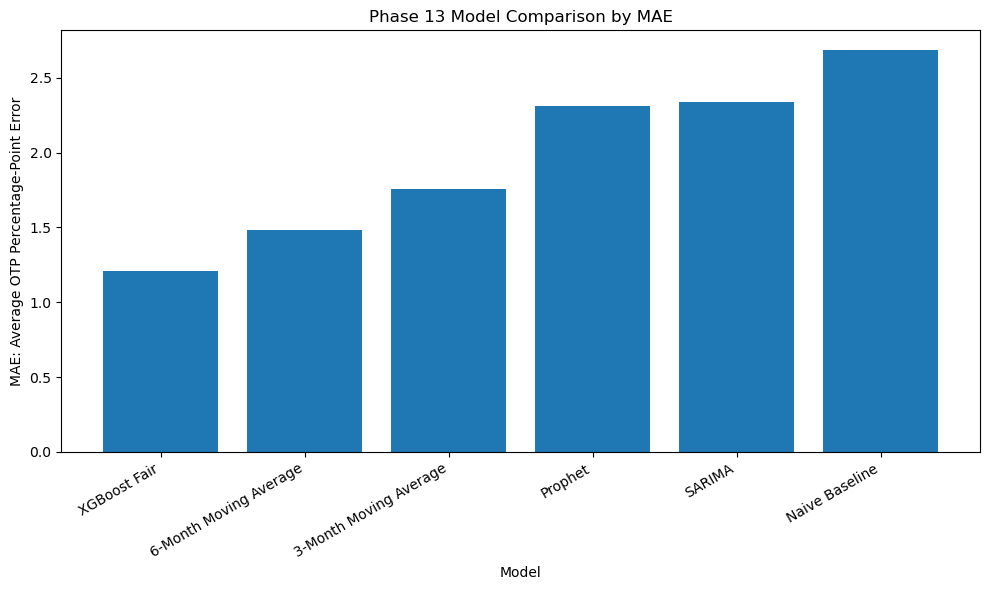

In [41]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df_rounded["Model"],
    comparison_df_rounded["MAE"]
)

plt.title("Phase 13 Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE: Average OTP Percentage-Point Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase13_model_comparison_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The XGBoost model produced the lowest MAE among all tested models. This means it had the smallest average OTP percentage-point error across the August 2025 to January 2026 test period.

The strongest simple baseline was the 6-month moving average. XGBoost still improved on this baseline, showing that the machine learning model added predictive value beyond simple historical averaging.

# Actual OTP vs Model Predictions

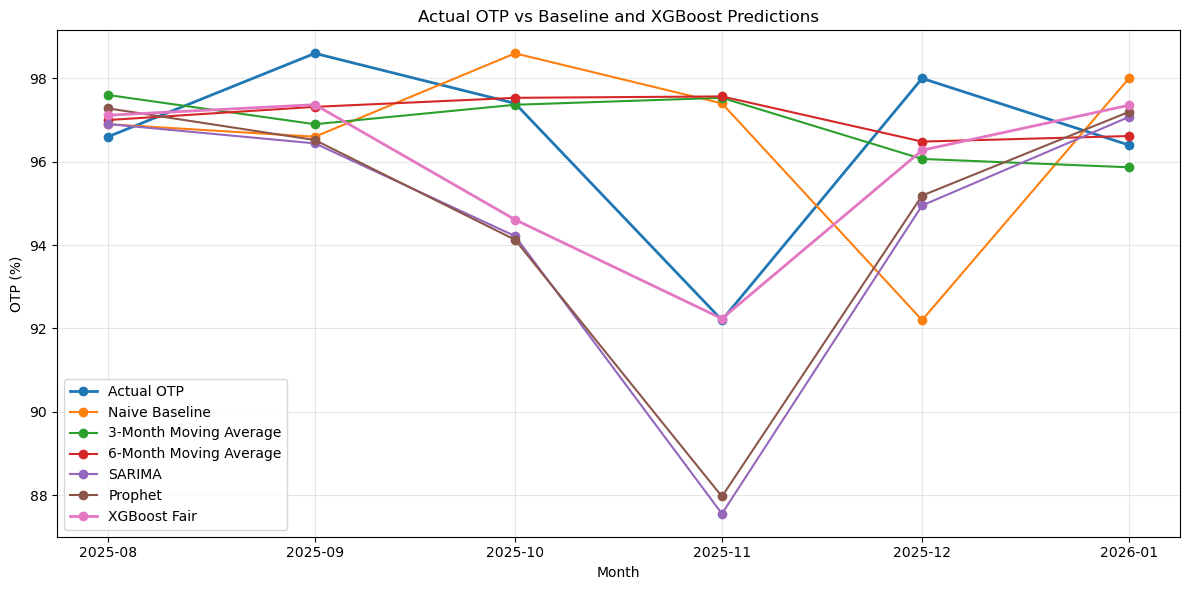

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(test["month"], test["otp"], marker="o", linewidth=2, label="Actual OTP")
plt.plot(test["month"], test["naive_pred"], marker="o", label="Naive Baseline")
plt.plot(test["month"], test["moving_avg_3_pred"], marker="o", label="3-Month Moving Average")
plt.plot(test["month"], test["moving_avg_6_pred"], marker="o", label="6-Month Moving Average")
plt.plot(test["month"], test["sarima_pred"], marker="o", label="SARIMA")
plt.plot(test["month"], test["prophet_pred"], marker="o", label="Prophet")
plt.plot(test["month"], test["xgb_fair_pred"], marker="o", linewidth=2, label="XGBoost Fair")

plt.title("Actual OTP vs Baseline and XGBoost Predictions")
plt.xlabel("Month")
plt.ylabel("OTP (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase13_actual_vs_baseline_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The actual-versus-predicted chart shows that most baseline models struggled during months with sharper OTP changes, especially November 2025. The naive and moving-average baselines overestimated OTP during that month, while SARIMA and Prophet underestimated it.

The fairly retrained XGBoost model followed the actual OTP pattern more closely during the test period, which explains its lower MAE and RMSE compared with the other models.

# Cleaner Chart with Top Models Only

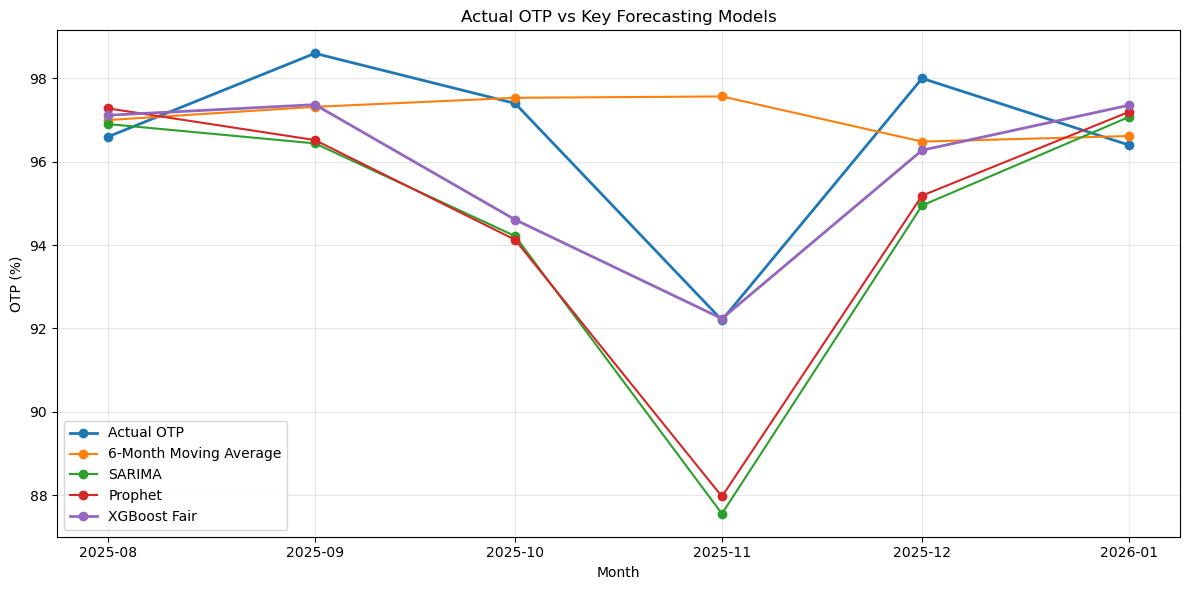

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(test["month"], test["otp"], marker="o", linewidth=2, label="Actual OTP")
plt.plot(test["month"], test["moving_avg_6_pred"], marker="o", label="6-Month Moving Average")
plt.plot(test["month"], test["sarima_pred"], marker="o", label="SARIMA")
plt.plot(test["month"], test["prophet_pred"], marker="o", label="Prophet")
plt.plot(test["month"], test["xgb_fair_pred"], marker="o", linewidth=2, label="XGBoost Fair")

plt.title("Actual OTP vs Key Forecasting Models")
plt.xlabel("Month")
plt.ylabel("OTP (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase13_actual_vs_key_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Phase 13 Findings

Phase 13 compared the XGBoost forecasting model against several baseline forecasting methods, including naive forecasting, 3-month moving average, 6-month moving average, SARIMA, and Prophet.

For a fair comparison, XGBoost was retrained using only data available before the test period. The model was trained through July 2025 and evaluated on August 2025 through January 2026. This avoids data leakage and ensures that the XGBoost results are directly comparable to the baseline methods.

The fair XGBoost model achieved the best performance, with an MAE of 1.2087 OTP percentage points and an RMSE of 1.4974. The strongest simple baseline was the 6-month moving average, with an MAE of 1.4861. This means XGBoost reduced average forecast error by approximately 18.7% compared with the strongest simple baseline.

The results also show that traditional statistical models such as SARIMA and Prophet did not perform as well during this test window. One likely reason is that the test period included a sharp OTP drop in November 2025, where XGBoost followed the actual OTP pattern more closely than the other models.

Overall, this phase supports the use of machine learning for short-horizon Staten Island Railway OTP forecasting, while also showing the importance of comparing against simple and statistical baselines.